In [ ]:
!pip install gdown pycocotools matplotlib seaborn opencv-python

import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("DATA_DIR:", os.path.abspath(DATA_DIR))

DATA_DIR: /content/data


In [ ]:
import gdown
import os

file_id = "1JfAa4Uw78kY1bwmZXdsd9azTy7y1kZC-"
url = f"https://drive.google.com/uc?id={file_id}"

anns_path = os.path.join("data", "annotations.json")
gdown.download(url, anns_path, quiet=False)

print("Downloaded annotations.json to:", os.path.abspath(anns_path))
print("Exists?", os.path.exists(anns_path))

Downloading...
From: https://drive.google.com/uc?id=1JfAa4Uw78kY1bwmZXdsd9azTy7y1kZC-
To: /content/data/annotations.json
100%|██████████| 3.02M/3.02M [00:00<00:00, 18.7MB/s]

Downloaded annotations.json to: /content/data/annotations.json
Exists? True


In [ ]:
import os
import json
from PIL import Image
import requests
from io import BytesIO
import sys

DATASET_PATH = "./data/annotations.json"
dataset_dir = os.path.dirname(DATASET_PATH)

with open(DATASET_PATH, "r") as f:
    annotations = json.load(f)

nr_images = len(annotations["images"])
print("Number of images:", nr_images)

for i, image in enumerate(annotations["images"]):
    file_name = image["file_name"]
    url_original = image["flickr_url"]

    file_path = os.path.join(dataset_dir, file_name)
    subdir = os.path.dirname(file_path)
    os.makedirs(subdir, exist_ok=True)

    if not os.path.isfile(file_path):
        response = requests.get(url_original)
        img = Image.open(BytesIO(response.content))
        img.save(file_path)

    bar_size = 30
    x = int(bar_size * (i+1) / nr_images)
    sys.stdout.write("%s[%s%s] - %i/%i\r" %
                     ("Loading: ", "=" * x, "." * (bar_size - x), i+1, nr_images))
    sys.stdout.flush()

sys.stdout.write("\nFinished\n")

Number of images: 1500

Finished


10

In [ ]:
import json

with open("data/annotations.json") as f:
    taco = json.load(f)

images = taco["images"]
annotations = taco["annotations"]
categories = taco["categories"]

print("num images:", len(images))
print("num annotations:", len(annotations))
print("num categories:", len(categories))

print("\nSample image entry:")
print(images[0])

print("\nSample annotation entry:")
print(annotations[0])

print("\nSample category entry:")
print(categories[0])

num images: 1500
num annotations: 4784
num categories: 60

Sample image entry:
{'id': 0, 'width': 1537, 'height': 2049, 'file_name': 'batch_1/000006.jpg', 'license': None, 'flickr_url': 'https://farm66.staticflickr.com/65535/33978196618_e30a59e0a8_o.png', 'coco_url': None, 'date_captured': None, 'flickr_640_url': 'https://farm66.staticflickr.com/65535/33978196618_632623b4fc_z.jpg'}

Sample annotation entry:
{'id': 1, 'image_id': 0, 'category_id': 6, 'segmentation': [[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0, 549.0, 1127.0, 538.0, 1089.0, 519.0, 1043.0, 517.0, 1005.0, 523.0, 964.0, 529.0, 945.0, 520.0, 896.0, 525.0, 862.0, 536.0, 821.0, 554.0, 769.0, 577.0, 727.0, 595.0, 678.0, 596.0, 585.0, 588.0, 346.0, 581.0, 328.0, 569.0, 306.0, 570.0, 276.0, 576.0, 224.0, 560.0, 205.0, 564.0, 170.0, 578.0, 154.0, 608.0, 136.0, 649.0, 127.0, 688.0, 127.0, 726.0, 129.0, 759.0, 141.0, 784.0, 153.0, 792.0, 177.0, 788.0, 193.0, 782.0, 209.0, 792.0, 238.0, 802.0, 271.0, 802.0, 294.0, 791.0, 319.0, 789

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cat_id_to_name = {c["id"]: c["name"] for c in categories}
cat_id_to_super = {c["id"]: c.get("supercategory", "unknown") for c in categories}

ann_df = pd.DataFrame(annotations)

ann_df["category_name"] = ann_df["category_id"].map(cat_id_to_name)
ann_df["supercategory"] = ann_df["category_id"].map(cat_id_to_super)

print("Annotations DataFrame shape:", ann_df.shape)
ann_df.head()

# CHECK NaN / MISSING VALUES

print("\n=== Missing values per column in ann_df ===")
print(ann_df.isna().sum())

print("\n=== Rows that contain at least one NaN ===")
nan_rows = ann_df[ann_df.isna().any(axis=1)]
print("Number of rows with NaN:", len(nan_rows))

if len(nan_rows) > 0:
    display(nan_rows.head(10))
else:
    print("No NaN rows found in annotations DataFrame.")

important_cols = ["id", "image_id", "category_id", "bbox"]
print("\n=== Missing values in important columns ===")
for col in important_cols:
    if col in ann_df.columns:
        print(f"{col}: {ann_df[col].isna().sum()}")
    else:
        print(f"{col}: column not found")

# STRUCTURAL VALIDATION OF ANNOTATIONS

print("\n=== Structural checks on annotations ===")

# 2.1 category_id
valid_cat_ids = set(cat_id_to_name.keys())
invalid_cat_rows = ann_df[~ann_df["category_id"].isin(valid_cat_ids)]
print("Invalid category_id rows:", len(invalid_cat_rows))

if len(invalid_cat_rows) > 0:
    display(invalid_cat_rows.head())

# 2.2 image_id
valid_image_ids = set([img["id"] for img in images])
invalid_image_rows = ann_df[~ann_df["image_id"].isin(valid_image_ids)]
print("Invalid image_id rows:", len(invalid_image_rows))

if len(invalid_image_rows) > 0:
    display(invalid_image_rows.head())

# 2.3 bbox
def invalid_bbox(bbox):
    if not isinstance(bbox, list) or len(bbox) != 4:
        return True
    x, y, w, h = bbox
    if w is None or h is None:
        return True
    if w <= 0 or h <= 0:
        return True
    return False

invalid_bbox_rows = ann_df[ann_df["bbox"].apply(invalid_bbox)]
print("Invalid bbox rows:", len(invalid_bbox_rows))

if len(invalid_bbox_rows) > 0:
    display(invalid_bbox_rows.head())

# 2.4 category_name that are not map
unmapped_category_rows = ann_df[ann_df["category_name"].isna()]
print("Rows with unmapped category_name:", len(unmapped_category_rows))

if len(unmapped_category_rows) > 0:
    display(unmapped_category_rows.head())


ann_df.head()

Annotations DataFrame shape: (4784, 9)

=== Missing values per column in ann_df ===
id               0
image_id         0
category_id      0
segmentation     0
area             0
bbox             0
iscrowd          0
category_name    0
supercategory    0
dtype: int64

=== Rows that contain at least one NaN ===
Number of rows with NaN: 0
No NaN rows found in annotations DataFrame.

=== Missing values in important columns ===
id: 0
image_id: 0
category_id: 0
bbox: 0

=== Structural checks on annotations ===
Invalid category_id rows: 0
Invalid image_id rows: 0
Invalid bbox rows: 0
Rows with unmapped category_name: 0


,id,image_id,category_id,segmentation,area,bbox,iscrowd,category_name,supercategory
0,1,0,6,"[[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0,...",403954.0,"[517.0, 127.0, 447.0, 1322.0]",0,Glass bottle,Bottle
1,2,1,18,"[[928.0, 1876.0, 938.0, 1856.0, 968.0, 1826.0,...",1071259.5,"[1.0, 457.0, 1429.0, 1519.0]",0,Meal carton,Carton
2,3,1,14,"[[617.0, 383.0, 703.0, 437.0, 713.0, 456.0, 72...",99583.5,"[531.0, 292.0, 1006.0, 672.0]",0,Other carton,Carton
3,4,2,5,"[[670.0, 993.0, 679.0, 998.0, 684.0, 1001.0, 6...",73832.5,"[632.0, 987.0, 500.0, 374.0]",0,Clear plastic bottle,Bottle
4,5,2,7,"[[647.0, 1028.0, 650.0, 1022.0, 653.0, 1016.0,...",915.0,"[632.0, 989.0, 44.0, 51.0]",0,Plastic bottle cap,Bottle cap


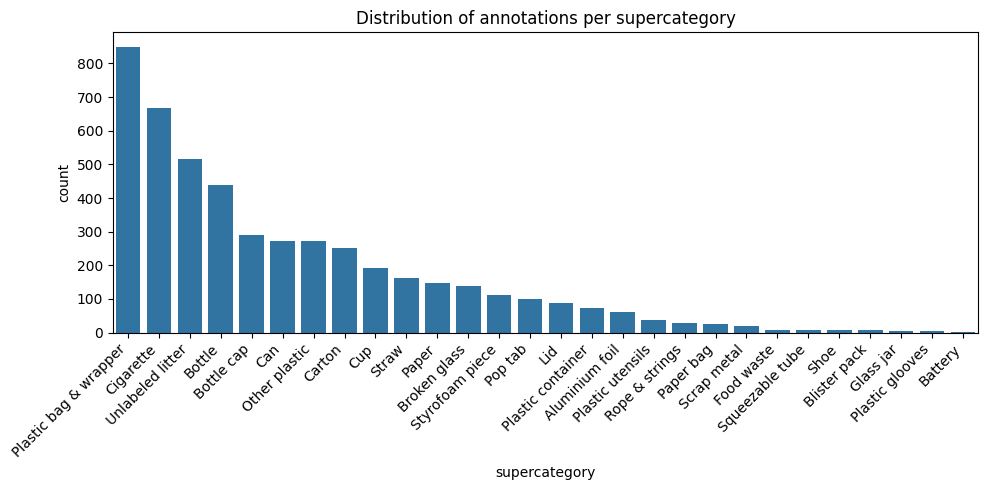

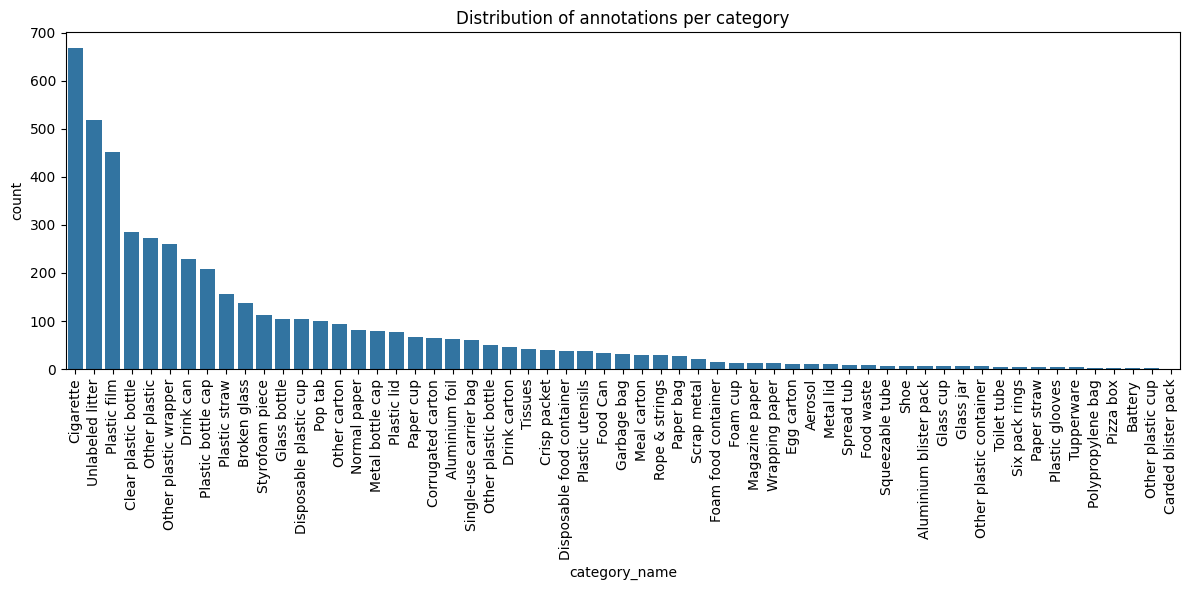

All categories (id, name, supercategory):


,id,name,supercategory
0,0,Aluminium foil,Aluminium foil
1,1,Battery,Battery
2,2,Aluminium blister pack,Blister pack
3,3,Carded blister pack,Blister pack
4,4,Other plastic bottle,Bottle
5,5,Clear plastic bottle,Bottle
6,6,Glass bottle,Bottle
7,7,Plastic bottle cap,Bottle cap
8,8,Metal bottle cap,Bottle cap
9,9,Broken glass,Broken glass



Categories used in annotations:


,id,name,supercategory
0,0,Aluminium foil,Aluminium foil
1,1,Battery,Battery
2,2,Aluminium blister pack,Blister pack
3,3,Carded blister pack,Blister pack
4,4,Other plastic bottle,Bottle
5,5,Clear plastic bottle,Bottle
6,6,Glass bottle,Bottle
7,7,Plastic bottle cap,Bottle cap
8,8,Metal bottle cap,Bottle cap
9,9,Broken glass,Broken glass



Category names (one per line):
- id= 0 | name=Aluminium foil | super=Aluminium foil
- id= 1 | name=Battery | super=Battery
- id= 2 | name=Aluminium blister pack | super=Blister pack
- id= 3 | name=Carded blister pack | super=Blister pack
- id= 4 | name=Other plastic bottle | super=Bottle
- id= 5 | name=Clear plastic bottle | super=Bottle
- id= 6 | name=Glass bottle | super=Bottle
- id= 7 | name=Plastic bottle cap | super=Bottle cap
- id= 8 | name=Metal bottle cap | super=Bottle cap
- id= 9 | name=Broken glass | super=Broken glass
- id=10 | name=Food Can | super=Can
- id=11 | name=Aerosol | super=Can
- id=12 | name=Drink can | super=Can
- id=13 | name=Toilet tube | super=Carton
- id=14 | name=Other carton | super=Carton
- id=15 | name=Egg carton | super=Carton
- id=16 | name=Drink carton | super=Carton
- id=17 | name=Corrugated carton | super=Carton
- id=18 | name=Meal carton | super=Carton
- id=19 | name=Pizza box | super=Carton
- id=20 | name=Paper cup | super=Cup
- id=21 | name=Disp

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=ann_df,
    x="supercategory",
    order=ann_df["supercategory"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of annotations per supercategory")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=ann_df,
    x="category_name",
    order=ann_df["category_name"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Distribution of annotations per category")
plt.tight_layout()
plt.show()


cat_df = pd.DataFrame(categories)
print("All categories (id, name, supercategory):")
display(cat_df[["id", "name", "supercategory"]].sort_values("id"))

used_cat_ids = sorted(ann_df["category_id"].unique())
used_cat_df = cat_df[cat_df["id"].isin(used_cat_ids)]

print("\nCategories used in annotations:")
display(used_cat_df[["id", "name", "supercategory"]].sort_values("id"))

print("\nCategory names (one per line):")
for _, row in used_cat_df.sort_values("id").iterrows():
    print(f"- id={row['id']:2d} | name={row['name']} | super={row['supercategory']}")


In [ ]:
# High-level class definitions and mappings

HIGH_LEVEL_CLASSES = [
    "Glass",
    "Metal",
    "PaperCard",
    "PlasticBottle",
    "PlasticFilmBag",
    "Container",
    "CigaretteItem",
    "CupItem",
    "BagWrapper",
    "MiscPlastic",
    "UnlabeledItem",
    "BottleCapItem",
    "Straw",
]

HIGH_LEVEL_MAP = {
    "Aluminium foil": "UnlabeledItem",
    "Battery": "UnlabeledItem",
    "Aluminium blister pack": "UnlabeledItem",
    "Carded blister pack": "UnlabeledItem",
    "Other plastic bottle": "PlasticBottle",
    "Clear plastic bottle": "PlasticBottle",
    "Glass bottle": "Glass",
    "Plastic bottle cap": "BottleCapItem",
    "Metal bottle cap": "BottleCapItem",
    "Broken glass": "Glass",
    "Food Can": "Metal",
    "Aerosol": "Metal",
    "Drink can": "Metal",
    "Toilet tube": "PaperCard",
    "Other carton": "PaperCard",
    "Egg carton": "PaperCard",
    "Drink carton": "PaperCard",
    "Corrugated carton": "PaperCard",
    "Meal carton": "PaperCard",
    "Pizza box": "PaperCard",
    "Paper cup": "CupItem",
    "Disposable plastic cup": "CupItem",
    "Foam cup": "CupItem",
    "Glass cup": "Glass",
    "Other plastic cup": "CupItem",
    "Food waste": "UnlabeledItem",
    "Glass jar": "Glass",
    "Plastic lid": "PlasticFilmBag",
    "Metal lid": "Metal",
    "Other plastic": "MiscPlastic",
    "Magazine paper": "PaperCard",
    "Tissues": "UnlabeledItem",
    "Wrapping paper": "PaperCard",
    "Normal paper": "PaperCard",
    "Paper bag": "PaperCard",
    "Plastic film": "PlasticFilmBag",
    "Six pack rings": "BagWrapper",
    "Garbage bag": "BagWrapper",
    "Other plastic wrapper": "BagWrapper",
    "Single-use carrier bag": "BagWrapper",
    "Polypropylene bag": "PlasticFilmBag",
    "Crisp packet": "BagWrapper",
    "Spread tub": "Container",
    "Tupperware": "Container",
    "Disposable food container": "Container",
    "Foam food container": "Container",
    "Other plastic container": "Container",
    "Plastic glooves": "MiscPlastic",
    "Plastic utensils": "MiscPlastic",
    "Pop tab": "Metal",
    "Rope & strings": "UnlabeledItem",
    "Scrap metal": "Metal",
    "Shoe": "UnlabeledItem",
    "Squeezable tube": "MiscPlastic",
    "Plastic straw": "Straw",
    "Paper straw": "Straw",
    "Styrofoam piece": "MiscPlastic",
    "Unlabeled litter": "UnlabeledItem",
    "Cigarette": "CigaretteItem",
}

CLASS_STATE = {
    "Glass": "recyclable",
    "Metal": "recyclable",
    "PaperCard": "recyclable",
    "PlasticBottle": "recyclable",
    "PlasticFilmBag": "recyclable",
    "Container": "recyclable",
    "BottleCapItem": "recyclable",

    "CigaretteItem": "non_recyclable",
    "CupItem": "non_recyclable",
    "BagWrapper": "non_recyclable",
    "MiscPlastic": "non_recyclable",
    "Straw": "non_recyclable",

    "UnlabeledItem": "unknown",
}


Unique high_level_class values: ['Glass' 'PaperCard' 'PlasticBottle' 'BottleCapItem' 'Metal' 'BagWrapper'
 'MiscPlastic' 'PlasticFilmBag' 'Container' 'CupItem' 'UnlabeledItem'
 'Straw' 'CigaretteItem']
Rows with NaN in high_level_class: 0


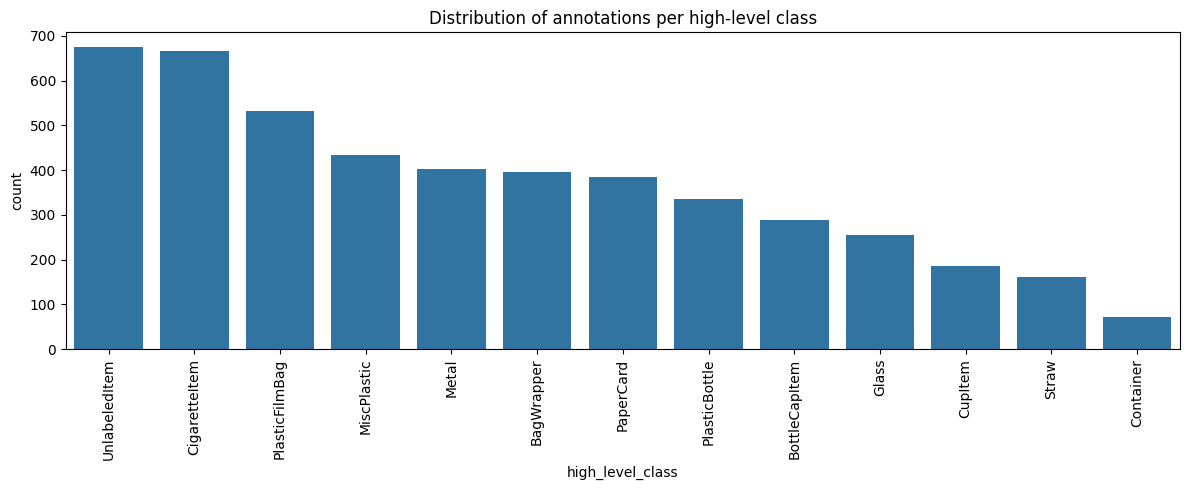

In [ ]:
# Mapping each annotation to a high-level class

ann_df["category_name"] = ann_df["category_id"].map(cat_id_to_name)

def map_to_high_level(name):
    if name in HIGH_LEVEL_MAP:
        return HIGH_LEVEL_MAP[name]
    else:
        return "UnlabeledItem"

ann_df["high_level_class"] = ann_df["category_name"].apply(map_to_high_level)

print("Unique high_level_class values:", ann_df["high_level_class"].unique())

missing_high = ann_df[ann_df["high_level_class"].isna()]
print("Rows with NaN in high_level_class:", len(missing_high))
if len(missing_high) > 0:
    display(missing_high.head())

plt.figure(figsize=(12, 5))
sns.countplot(
    data=ann_df,
    x="high_level_class",
    order=ann_df["high_level_class"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Distribution of annotations per high-level class")
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import random
from collections import Counter, defaultdict

random.seed(42)

images = taco["images"]
annotations = taco["annotations"]
categories = taco["categories"]

all_image_ids = [img["id"] for img in images]
cat_id_to_name = {c["id"]: c["name"] for c in categories}

print(f"Total images: {len(all_image_ids)}")
print(f"Total annotations: {len(annotations)}")

def ann_high_class(ann):
    old_cid = ann["category_id"]
    old_name = cat_id_to_name[old_cid]
    return HIGH_LEVEL_MAP.get(old_name, "UnlabeledItem")

# annotations per image
image_to_annotations = defaultdict(list)
for ann in annotations:
    image_to_annotations[ann["image_id"]].append(ann)

for img_id in all_image_ids:
    if img_id not in image_to_annotations:
        image_to_annotations[img_id] = []

global_high_counts = Counter()
for ann in annotations:
    high_name = ann_high_class(ann)
    global_high_counts[high_name] += 1

print("\nGlobal HIGH-LEVEL class counts:")
for cname, cnt in global_high_counts.most_common():
    print(f"{cname:25s} -> {cnt}")

n_total = len(all_image_ids)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

print("\nTarget sizes:")
print("Total:", n_total)
print("Train:", n_train, " Val:", n_val, " Test:", n_test)

max_train_fraction = 0.8
class_train_cap = {
    cname: int(max_train_fraction * cnt)
    for cname, cnt in global_high_counts.items()
}

print("\nPer-class train caps (max number of annotations per class in train):")
for cname, cap in class_train_cap.items():
    print(f"{cname:25s} -> {cap} (of {global_high_counts[cname]})")

selected_train = []
remaining = set(all_image_ids)

train_high_counts = Counter()

def image_gain(img_id, train_counts, global_counts, class_cap):
    anns = image_to_annotations[img_id]
    if not anns:
        return 0.0

    local_counts = Counter()
    for ann in anns:
        high_name = ann_high_class(ann)
        local_counts[high_name] += 1

    gain = 0.0
    for high_name, cnt in local_counts.items():
        if train_counts[high_name] >= class_cap[high_name]:
            continue

        available = class_cap[high_name] - train_counts[high_name]
        effective_cnt = min(cnt, available)

        if effective_cnt <= 0:
            continue

        gain += effective_cnt / (1 + train_counts[high_name]) * (1 / global_counts[high_name])

    return gain

while len(selected_train) < n_train and remaining:
    best_img = None
    best_score = -1.0

    for img_id in remaining:
        score = image_gain(img_id, train_high_counts, global_high_counts, class_train_cap)
        if score > best_score:
            best_score = score
            best_img = img_id

    if best_img is None or best_score <= 0.0:
        print("\nNo more useful train images based on class caps; stopping greedy early.")
        break

    selected_train.append(best_img)
    remaining.remove(best_img)

    for ann in image_to_annotations[best_img]:
        high_name = ann_high_class(ann)
        train_high_counts[high_name] += 1

if len(selected_train) < n_train:
    needed = n_train - len(selected_train)
    print(f"\nFilling remaining {needed} train images randomly (caps exhausted).")
    remaining_ids_tmp = list(remaining)
    random.shuffle(remaining_ids_tmp)
    extra_train = remaining_ids_tmp[:needed]
    selected_train.extend(extra_train)
    remaining = set(remaining_ids_tmp[needed:])

train_image_ids = selected_train

remaining_ids = list(remaining)
random.shuffle(remaining_ids)

val_image_ids = remaining_ids[:n_val]
test_image_ids = remaining_ids[n_val:n_val+n_test]

print("\nActual split sizes:")
print("Train:", len(train_image_ids))
print("Val  :", len(val_image_ids))
print("Test :", len(test_image_ids))

print("\nTrain HIGH-LEVEL class counts:")
for cname, cnt in train_high_counts.most_common():
    print(f"{cname:25s} -> {cnt}")

def make_coco_subset(selected_image_ids, all_data):
    imgs = {img["id"]: img for img in all_data["images"]}
    subset_images = [imgs[i] for i in selected_image_ids]
    subset_image_id_set = set(selected_image_ids)

    subset_annotations = [
        ann for ann in all_data["annotations"]
        if ann["image_id"] in subset_image_id_set
    ]

    subset = {
        "info": all_data.get("info", {}),
        "licenses": all_data.get("licenses", []),
        "categories": all_data.get("categories", []),
        "images": subset_images,
        "annotations": subset_annotations,
    }
    return subset

train_data = make_coco_subset(train_image_ids, taco)
val_data   = make_coco_subset(val_image_ids, taco)
test_data  = make_coco_subset(test_image_ids, taco)

print("\nAnnotation counts:")
print("Train annotations:", len(train_data["annotations"]))
print("Val annotations:", len(val_data["annotations"]))
print("Test annotations:", len(test_data["annotations"]))


Total images: 1500
Total annotations: 4784

Global HIGH-LEVEL class counts:
UnlabeledItem             -> 674
CigaretteItem             -> 667
PlasticFilmBag            -> 531
MiscPlastic               -> 433
Metal                     -> 402
BagWrapper                -> 396
PaperCard                 -> 384
PlasticBottle             -> 335
BottleCapItem             -> 289
Glass                     -> 254
CupItem                   -> 186
Straw                     -> 161
Container                 -> 72

Target sizes:
Total: 1500
Train: 1050  Val: 225  Test: 225

Per-class train caps (max number of annotations per class in train):
Glass                     -> 203 (of 254)
PaperCard                 -> 307 (of 384)
PlasticBottle             -> 268 (of 335)
BottleCapItem             -> 231 (of 289)
Metal                     -> 321 (of 402)
BagWrapper                -> 316 (of 396)
MiscPlastic               -> 346 (of 433)
PlasticFilmBag            -> 424 (of 531)
Container                 -> 5

In [ ]:
# Build mapping high_level_class → new category_id

high_class_to_id = {name: i + 1 for i, name in enumerate(HIGH_LEVEL_CLASSES)}
id_to_high_class = {v: k for k, v in high_class_to_id.items()}

print("High-level class → id:")
for k, v in high_class_to_id.items():
    print(f"{v:2d} : {k}")

# new COCO categories
new_categories = []
for class_name, cid in high_class_to_id.items():
    new_categories.append({
        "id": cid,
        "name": class_name,
        "supercategory": "waste"
    })


High-level class → id:
 1 : Glass
 2 : Metal
 3 : PaperCard
 4 : PlasticBottle
 5 : PlasticFilmBag
 6 : Container
 7 : CigaretteItem
 8 : CupItem
 9 : BagWrapper
10 : MiscPlastic
11 : UnlabeledItem
12 : BottleCapItem
13 : Straw


In [ ]:
# Remap a COCO dict to high-level categories

def remap_coco_to_highlevel(coco_data):
    cat_id_to_name_local = {c["id"]: c["name"] for c in coco_data["categories"]}

    new_annotations = []
    for ann in coco_data["annotations"]:
        old_cat_id = ann["category_id"]
        old_name = cat_id_to_name_local[old_cat_id]

        high_name = HIGH_LEVEL_MAP.get(old_name, "UnlabeledItem")
        new_cat_id = high_class_to_id[high_name]

        new_ann = ann.copy()
        new_ann["category_id"] = new_cat_id
        new_annotations.append(new_ann)

    new_coco = {
        "info": coco_data.get("info", {}),
        "licenses": coco_data.get("licenses", []),
        "images": coco_data["images"],
        "categories": new_categories,
        "annotations": new_annotations,
    }
    return new_coco


In [ ]:
# Build and save high-level COCO splits

train_data_high = remap_coco_to_highlevel(train_data)
val_data_high   = remap_coco_to_highlevel(val_data)
test_data_high  = remap_coco_to_highlevel(test_data)

import json
from pathlib import Path

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

save_json(train_data_high, "data/splits_high/annotations_train_high.json")
save_json(val_data_high,   "data/splits_high/annotations_val_high.json")
save_json(test_data_high,  "data/splits_high/annotations_test_high.json")

print("High-level subset JSON files saved successfully.")
print("Train_high annotations:", len(train_data_high["annotations"]))
print("Val_high annotations:", len(val_data_high["annotations"]))
print("Test_high annotations:", len(test_data_high["annotations"]))


High-level subset JSON files saved successfully.
Train_high annotations: 4194
Val_high annotations: 296
Test_high annotations: 294


In [ ]:
# Check that there is no overlap between splits

s_train = set(train_image_ids)
s_val = set(val_image_ids)
s_test = set(test_image_ids)

print("train ∩ val:", len(s_train & s_val))
print("train ∩ test:", len(s_train & s_test))
print("val ∩ test:", len(s_val & s_test))

assert s_train.isdisjoint(s_val)
assert s_train.isdisjoint(s_test)
assert s_val.isdisjoint(s_test)

print("No overlap between splits")


train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
No overlap between splits


In [ ]:
from pathlib import Path
import json

ROOT = Path(".")
DATA_DIR = ROOT / "data"
IMAGES_ROOT = DATA_DIR

SPLITS_HIGH_DIR = DATA_DIR / "splits_high"

train_json_path = SPLITS_HIGH_DIR / "annotations_train_high.json"
val_json_path   = SPLITS_HIGH_DIR / "annotations_val_high.json"
test_json_path  = SPLITS_HIGH_DIR / "annotations_test_high.json"

print("Train JSON exists:", train_json_path.exists())
print("Val JSON exists:", val_json_path.exists())
print("Test JSON exists:", test_json_path.exists())


Train JSON exists: True
Val JSON exists: True
Test JSON exists: True


In [ ]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_high = load_json(train_json_path)
val_high   = load_json(val_json_path)
test_high  = load_json(test_json_path)

print("Train_high images:", len(train_high["images"]))
print("Train_high annotations:", len(train_high["annotations"]))

high_level_categories = train_high["categories"]
print("High-level categories:")
for c in high_level_categories:
    print(c["id"], "→", c["name"])


Train_high images: 1050
Train_high annotations: 4194
High-level categories:
1 → Glass
2 → Metal
3 → PaperCard
4 → PlasticBottle
5 → PlasticFilmBag
6 → Container
7 → CigaretteItem
8 → CupItem
9 → BagWrapper
10 → MiscPlastic
11 → UnlabeledItem
12 → BottleCapItem
13 → Straw


In [ ]:
high_names = [c["name"] for c in high_level_categories]

yolo_class_to_id = {name: i for i, name in enumerate(high_names)}
id_to_yolo_class = {i: name for name, i in yolo_class_to_id.items()}

print("YOLO class mapping:")
for name, idx in yolo_class_to_id.items():
    print(f"{idx:2d} : {name}")


YOLO class mapping:
 0 : Glass
 1 : Metal
 2 : PaperCard
 3 : PlasticBottle
 4 : PlasticFilmBag
 5 : Container
 6 : CigaretteItem
 7 : CupItem
 8 : BagWrapper
 9 : MiscPlastic
10 : UnlabeledItem
11 : BottleCapItem
12 : Straw


In [ ]:
def coco_ann_to_yolo_line(ann, image_lookup, yolo_class_to_id, high_categories):
    img = image_lookup[ann["image_id"]]
    img_w = img["width"]
    img_h = img["height"]

    x_min, y_min, w, h = ann["bbox"]
    x_center = x_min + w / 2.0
    y_center = y_min + h / 2.0

    x_center_norm = x_center / img_w
    y_center_norm = y_center / img_h
    w_norm = w / img_w
    h_norm = h / img_h

    # cat_id high-level → class name
    cat_id_to_name = {c["id"]: c["name"] for c in high_categories}
    class_name = cat_id_to_name[ann["category_id"]]
    class_id = yolo_class_to_id[class_name]

    return class_id, x_center_norm, y_center_norm, w_norm, h_norm


In [ ]:
YOLO_ROOT = DATA_DIR / "yolo_high"
IMAGES_YOLO = YOLO_ROOT / "images"
LABELS_YOLO = YOLO_ROOT / "labels"

for sub in ["train", "val", "test"]:
    (IMAGES_YOLO / sub).mkdir(parents=True, exist_ok=True)
    (LABELS_YOLO / sub).mkdir(parents=True, exist_ok=True)

print("YOLO dirs created under:", YOLO_ROOT)


YOLO dirs created under: data/yolo_high


In [ ]:
import os
from pathlib import Path

def generate_yolo_labels_for_split(coco_split, split_name, images_root, labels_root, yolo_class_to_id):
    image_lookup = {img["id"]: img for img in coco_split["images"]}
    split_labels_dir = labels_root / split_name
    split_labels_dir.mkdir(parents=True, exist_ok=True)
    high_categories = coco_split["categories"]

    anns_by_image = {}
    for ann in coco_split["annotations"]:
        img_id = ann["image_id"]
        anns_by_image.setdefault(img_id, []).append(ann)

    print(f"Generating YOLO labels for split '{split_name}' ...")
    for img_id, img in image_lookup.items():
        file_name = img["file_name"]

        unique_name = file_name.replace("/", "_").replace("\\", "_")
        stem = Path(unique_name).stem

        label_path = split_labels_dir / f"{stem}.txt"
        anns = anns_by_image.get(img_id, [])
        lines = []
        for ann in anns:
            cls_id, xc, yc, w, h = coco_ann_to_yolo_line(
                ann, image_lookup, yolo_class_to_id, high_categories
            )
            lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

        with open(label_path, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

    print(f"Labels written to: {split_labels_dir}")



In [ ]:
generate_yolo_labels_for_split(
    train_high, "train", IMAGES_ROOT, LABELS_YOLO, yolo_class_to_id
)
generate_yolo_labels_for_split(
    val_high, "val", IMAGES_ROOT, LABELS_YOLO, yolo_class_to_id
)
generate_yolo_labels_for_split(
    test_high, "test", IMAGES_ROOT, LABELS_YOLO, yolo_class_to_id
)

Generating YOLO labels for split 'train' ...
Labels written to: data/yolo_high/labels/train
Generating YOLO labels for split 'val' ...
Labels written to: data/yolo_high/labels/val
Generating YOLO labels for split 'test' ...
Labels written to: data/yolo_high/labels/test


In [ ]:
import shutil
from pathlib import Path

def copy_images_for_split(coco_split, split_name, images_root, images_yolo_root):
    split_images_dir = images_yolo_root / split_name
    split_images_dir.mkdir(parents=True, exist_ok=True)
    image_lookup = {img["id"]: img for img in coco_split["images"]}

    print(f"Copying images for '{split_name}' ...")

    for img in image_lookup.values():
        file_rel = img["file_name"]
        src_path = images_root / file_rel

        unique_name = file_rel.replace("/", "_").replace("\\", "_")
        dst_path = split_images_dir / unique_name

        if not src_path.exists():
            print("WARNING: missing image:", src_path)
            continue

        shutil.copy2(src_path, dst_path)

    print(f"[{split_name}] images copied to:", split_images_dir)



In [ ]:
copy_images_for_split(train_high, "train", IMAGES_ROOT, IMAGES_YOLO)
copy_images_for_split(val_high,   "val",   IMAGES_ROOT, IMAGES_YOLO)
copy_images_for_split(test_high,  "test",  IMAGES_ROOT, IMAGES_YOLO)

Copying images for 'train' ...
[train] images copied to: data/yolo_high/images/train
Copying images for 'val' ...
[val] images copied to: data/yolo_high/images/val
Copying images for 'test' ...
[test] images copied to: data/yolo_high/images/test


In [ ]:
yaml_path = YOLO_ROOT / "taco_high.yaml"

names_list = [id_to_yolo_class[i] for i in range(len(id_to_yolo_class))]

yaml_content = f"""
path: {YOLO_ROOT}

train: images/train
val: images/val
test: images/test

names:
"""

for i, name in enumerate(names_list):
    yaml_content += f"  {i}: {name}\n"

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_content.strip())

print("YAML written to:", yaml_path)
print("Class names:", names_list)


YAML written to: data/yolo_high/taco_high.yaml
Class names: ['Glass', 'Metal', 'PaperCard', 'PlasticBottle', 'PlasticFilmBag', 'Container', 'CigaretteItem', 'CupItem', 'BagWrapper', 'MiscPlastic', 'UnlabeledItem', 'BottleCapItem', 'Straw']


In [ ]:
!pip install -q ultralytics

from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    erasing=0.1,
    name="taco_high_exp1",
    project=str(YOLO_ROOT / "runs")
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_high/taco_high.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=taco_high_exp1, nbs=64, nms=Fals

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/data/yolo_high/runs/taco_high_exp1/weights/best.pt")

metrics = model.val(
    data="/content/data/yolo_high/taco_high.yaml",
    split="test",
    imgsz=640,
    conf=0.001,
    iou=0.7,
    batch=16,
    plots=True,
    save_json=True,
)

print(metrics)


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,130,615 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 142.3±29.8 MB/s, size: 1872.5 KB)
val: Scanning /content/data/yolo_high/labels/test... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 457.4it/s 0.5s
val: New cache created: /content/data/yolo_high/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.2it/s 12.8s
                   all        225        294      0.291      0.252      0.204      0.162
                 Glass         13         16       0.17     0.0625     0.0603     0.0403
                 Metal         23         25      0.479      0.331       0.37      0.298
             PaperCard         26         26      0.467      0.308      0.282      0.232
         PlasticBottle         23         23      0.302      0.261  

In [ ]:
HIGH_LEVEL_CLASSES = names_list

CLASS_STATE = {
    "Glass": "recyclable",
    "Metal": "recyclable",
    "PaperCard": "recyclable",
    "PlasticBottle": "recyclable",
    "PlasticFilmBag": "recyclable",
    "Container": "recyclable",
    "BottleCapItem": "recyclable",

    "CigaretteItem": "non_recyclable",
    "CupItem": "non_recyclable",
    "BagWrapper": "non_recyclable",
    "MiscPlastic": "non_recyclable",
    "Straw": "non_recyclable",

    "UnlabeledItem": "unknown",
}

CONF_UNKNOWN_THRESHOLD = 0.15

def interpret_detection(cls_id: int, conf: float):
    high_class = HIGH_LEVEL_CLASSES[cls_id]

    if conf < CONF_UNKNOWN_THRESHOLD:
        return {
            "high_class": high_class,
            "state": "unknown",
            "reason": "low_confidence",
        }

    if high_class == "UnlabeledItem":
        return {
            "high_class": high_class,
            "state": "unknown",
            "reason": "unlabeled_class",
        }

    state = CLASS_STATE[high_class]

    return {
        "high_class": high_class,
        "state": state,  # recyclable / non_recyclable
        "reason": "none",
    }

In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import cv2
import numpy as np
import glob

TEST_IMAGES_DIR = "/content/data/yolo_high/images/test"
OUTPUT_VIS_DIR = "/content/data/yolo_high/test_visuals"

os.makedirs(OUTPUT_VIS_DIR, exist_ok=True)

model = YOLO("/content/runs/detect/data/yolo_high/runs/taco_high_exp1/weights/best.pt")

In [ ]:
image_paths = sorted(
    glob.glob(str(Path(TEST_IMAGES_DIR) / "*.jpg"))
    + glob.glob(str(Path(TEST_IMAGES_DIR) / "*.png"))
)
max_images = 30
image_paths = image_paths[:max_images]

def draw_box_and_text(img_bgr, box, info, conf):

    # bbox coords (xyxy)
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    if info["state"] == "recyclable":
        color = (0, 255, 0)
    elif info["state"] == "non_recyclable":
        color = (0, 0, 255)
    else:
        color = (0, 255, 255)

    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 2)

    label = f"{info['high_class']} ({info['state']}, {conf:.2f})"
    (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(img_bgr, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
    cv2.putText(
        img_bgr,
        label,
        (x1, y1 - 2),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),
        1,
        cv2.LINE_AA,
    )

    return img_bgr
for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        print("Could not read:", img_path)
        continue

    results = model(img)[0]

    for box in results.boxes:
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        info = interpret_detection(cls_id, conf)
        img = draw_box_and_text(img, box, info, conf)

    fname = Path(img_path).name
    out_path = Path(OUTPUT_VIS_DIR) / fname
    cv2.imwrite(str(out_path), img)
    print("Saved vis:", out_path)


0: 320x640 1 PlasticFilmBag, 1 MiscPlastic, 10.4ms
Speed: 2.7ms preprocess, 10.4ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)
Saved vis: /content/data/yolo_high/test_visuals/batch_10_000017.jpg

0: 320x640 2 PlasticFilmBags, 1 MiscPlastic, 10.5ms
Speed: 2.5ms preprocess, 10.5ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)
Saved vis: /content/data/yolo_high/test_visuals/batch_10_000018.jpg

0: 640x320 1 PaperCard, 43.7ms
Speed: 2.7ms preprocess, 43.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 320)
Saved vis: /content/data/yolo_high/test_visuals/batch_10_000023.jpg

0: 640x320 (no detections), 10.5ms
Speed: 2.5ms preprocess, 10.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 320)
Saved vis: /content/data/yolo_high/test_visuals/batch_10_000045.jpg

0: 640x320 1 PlasticFilmBag, 10.5ms
Speed: 2.4ms preprocess, 10.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 320)
Saved vis: /content/data/yolo_hig

In [ ]:
from collections import Counter

state_counter = Counter()
class_counter = Counter()
reason_counter = Counter()

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue
    results = model(img)[0]

    for box in results.boxes:
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        info = interpret_detection(cls_id, conf)

        state_counter[info["state"]] += 1
        class_counter[info["high_class"]] += 1
        reason_counter[info["reason"]] += 1

print("State counts:", state_counter)
print("Class counts:", class_counter)
print("Unknown reasons:", reason_counter)


0: 320x640 1 PlasticFilmBag, 1 MiscPlastic, 11.6ms
Speed: 3.0ms preprocess, 11.6ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 2 PlasticFilmBags, 1 MiscPlastic, 10.5ms
Speed: 3.0ms preprocess, 10.5ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 640)

0: 640x320 1 PaperCard, 18.8ms
Speed: 4.2ms preprocess, 18.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 320)

0: 640x320 (no detections), 11.4ms
Speed: 3.1ms preprocess, 11.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 320)

0: 640x320 1 PlasticFilmBag, 11.5ms
Speed: 3.0ms preprocess, 11.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 320)

0: 320x640 2 PlasticFilmBags, 2 MiscPlastics, 14.3ms
Speed: 2.7ms preprocess, 14.3ms inference, 2.0ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 PlasticFilmBag, 11.0ms
Speed: 3.5ms preprocess, 11.0ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 Plasti

In [ ]:
import pandas as pd

df_states = pd.DataFrame(
    [
        {"state": s, "count": c}
        for s, c in state_counter.items()
    ]
)
print(df_states)

df_classes = pd.DataFrame(
    [
        {"class": cls, "count": c}
        for cls, c in class_counter.items()
    ]
)
print(df_classes.sort_values("count", ascending=False))

            state  count
0  non_recyclable     11
1      recyclable     33
2         unknown      3
             class  count
1   PlasticFilmBag     15
0      MiscPlastic      8
6    BottleCapItem      7
3    PlasticBottle      4
2        PaperCard      3
5    UnlabeledItem      3
9            Metal      2
4            Glass      1
7       BagWrapper      1
8        Container      1
10         CupItem      1
11           Straw      1


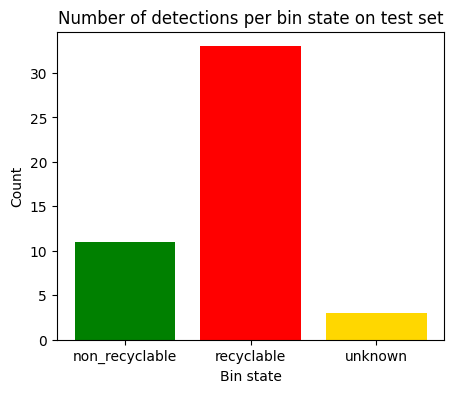

In [ ]:
import matplotlib.pyplot as plt

states = list(state_counter.keys())
counts = [state_counter[s] for s in states]

plt.figure(figsize=(5,4))
plt.bar(states, counts, color=["green", "red", "gold"])
plt.xlabel("Bin state")
plt.ylabel("Count")
plt.title("Number of detections per bin state on test set")
plt.show()

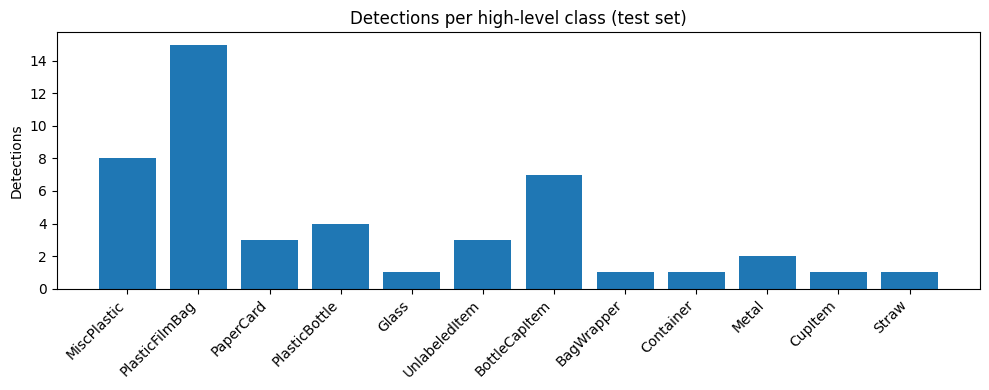

In [ ]:
cls_names = list(class_counter.keys())
cls_counts = [class_counter[c] for c in cls_names]

plt.figure(figsize=(10,4))
plt.bar(cls_names, cls_counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Detections")
plt.title("Detections per high-level class (test set)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# mAP
map50_95 = float(metrics.box.map)      # mAP@0.5:0.95
map50     = float(metrics.box.maps[0]) # mAP@0.5

# precision / recall
# metrics.box.mp  -> mean precision
# metrics.box.mr  -> mean recall
mean_precision = float(metrics.box.mp)
mean_recall    = float(metrics.box.mr)

# F1 macro-style
if (mean_precision + mean_recall) > 0:
    mean_f1 = 2 * mean_precision * mean_recall / (mean_precision + mean_recall)
else:
    mean_f1 = 0.0

# accuracy
try:
    total_tp = metrics.box.tp.sum()
    total = metrics.box.total.sum()
    overall_acc = total_tp / total if total > 0 else 0.0
except Exception:
    overall_acc = None

rows = [
    {
        "metric": "mean_precision",
        "value": mean_precision,
    },
    {
        "metric": "mean_recall",
        "value": mean_recall,
    },
    {
        "metric": "mean_f1",
        "value": mean_f1,
    },
    {
        "metric": "mAP50",
        "value": map50,
    },
    {
        "metric": "mAP50-95",
        "value": map50_95,
    },
]

if overall_acc is not None:
    rows.append({
        "metric": "approx_accuracy",
        "value": overall_acc,
    })

df_overall = pd.DataFrame(rows)
print("\n===== Overall detection metrics (test) =====")
print(df_overall.to_string(index=False))


===== Overall detection metrics (test) =====
        metric    value
mean_precision 0.290932
   mean_recall 0.252328
       mean_f1 0.270258
         mAP50 0.040318
      mAP50-95 0.162064
